---
# Multi-Model Comparison

This section trains and compares four anomaly detection models on the same HDFS log sequences:

| # | Model | Type | Key idea |
|---|-------|------|----------|
| 1 | **LSTM Autoencoder** | Deep learning | Reconstruct sequences; high error = anomaly |
| 2 | **GRU Autoencoder** | Deep learning | Same idea as LSTM, fewer parameters |
| 3 | **Isolation Forest** | Tree ensemble | Anomalies are easier to isolate in random trees |
| 4 | **One-Class SVM** | Kernel method | Learns a boundary around normal data |


In [6]:
# ── Imports ──────────────────────────────────────────────────────────────
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix
import sys, os
sys.path.insert(0, '../src')

from model_training import (
    LSTMAutoencoder,
    GRUAutoencoder,
    IsolationForestDetector,
    OneClassSVMDetector,
)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Colour palette – one per model
MODEL_COLORS = {
    'LSTM Autoencoder': '#4C72B0',
    'GRU Autoencoder':  '#DD8452',
    'Isolation Forest': '#55A868',
    'One-Class SVM':    '#C44E52',
}

print('Imports OK')

Imports OK


## Step 1 – Train all models

In [8]:
train_seq = np.load('../data/processed/train_sequences.npy')
test_seq  = np.load('../data/processed/test_sequences.npy')
print(f'Train: {train_seq.shape}   Test: {test_seq.shape}')

results = {}   # { model_name: {'labels':..., 'scores':...} }

# ── 1. LSTM ───────────────────────────────────────────────────────────────
lstm = LSTMAutoencoder('../config.yaml')
lstm.train(train_seq, test_seq)
results['LSTM Autoencoder'] = dict(
    labels    = lstm.predict(test_seq),
    scores    = lstm.anomaly_scores(test_seq),
    errors    = lstm.reconstruction_errors(test_seq),
    threshold = lstm.threshold,
)

# ── 2. GRU ────────────────────────────────────────────────────────────────
gru = GRUAutoencoder('../config.yaml')
gru.train(train_seq, test_seq)
results['GRU Autoencoder'] = dict(
    labels    = gru.predict(test_seq),
    scores    = gru.anomaly_scores(test_seq),
    errors    = gru.reconstruction_errors(test_seq),
    threshold = gru.threshold,
)

# ── 3. Isolation Forest ───────────────────────────────────────────────────
iso = IsolationForestDetector('../config.yaml')
iso.train(train_seq, test_seq)
results['Isolation Forest'] = dict(
    labels = iso.predict(test_seq),
    scores = iso.anomaly_scores(test_seq),
)

# ── 4. One-Class SVM ──────────────────────────────────────────────────────
ocsvm = OneClassSVMDetector('../config.yaml')
ocsvm.train(train_seq, test_seq)
results['One-Class SVM'] = dict(
    labels = ocsvm.predict(test_seq),
    scores = ocsvm.anomaly_scores(test_seq),
)

print('\nAll models trained!')

2026-04-20 14:22:40.113 | INFO     | model_training:train:74 - [LSTM] Starting training...
2026-04-20 14:22:40.143 | INFO     | model_training:build_model:52 - Building LSTM Autoencoder...


Train: (1393, 10)   Test: (597, 10)


C:\Users\smrit\anaconda3\envs\log-anomaly\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 10, 32)              │          33,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 10, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 10, 1056)            │          68,640 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

...

Saved artifact at 'models/gru_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 10, 1056), dtype=tf.float32, name=None)
Captures:
  1851157009104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1851157010864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1851157007872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1851157008224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1851190317248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1851157010688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1851190318128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1851190326400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1851190319712: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-04-20 14:31:04.924 | INFO     | model_training:train:203 - [GRU] Training complete. Threshold=617981.726283


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


2026-04-20 14:31:08.976 | INFO     | model_training:train:251 - [IsolationForest] Starting training...
2026-04-20 14:31:11.860 | INFO     | model_training:train:256 - [IsolationForest] Training complete.
2026-04-20 14:31:12.233 | INFO     | model_training:train:293 - [OneClassSVM] Starting training (may take a minute)...
2026-04-20 14:31:12.316 | INFO     | model_training:train:298 - [OneClassSVM] Training complete.



All models trained!


## Step 2 – Quick summary table

In [15]:
import pandas as pd

rows = []
for name, res in results.items():
    n_anom = int(res['labels'].sum())
    n_norm = len(res['labels']) - n_anom
    pct    = n_anom / len(res['labels']) * 100
    rows.append({'Model': name, 'Normal': n_norm, 'Anomalies': n_anom, 'Anomaly %': round(pct, 1)})

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())

                  Normal  Anomalies  Anomaly %
Model                                         
LSTM Autoencoder     565         32        5.4
GRU Autoencoder      565         32        5.4
Isolation Forest     566         31        5.2
One-Class SVM        542         55        9.2


## Step 3 – Visualisation 1: Anomaly counts bar chart

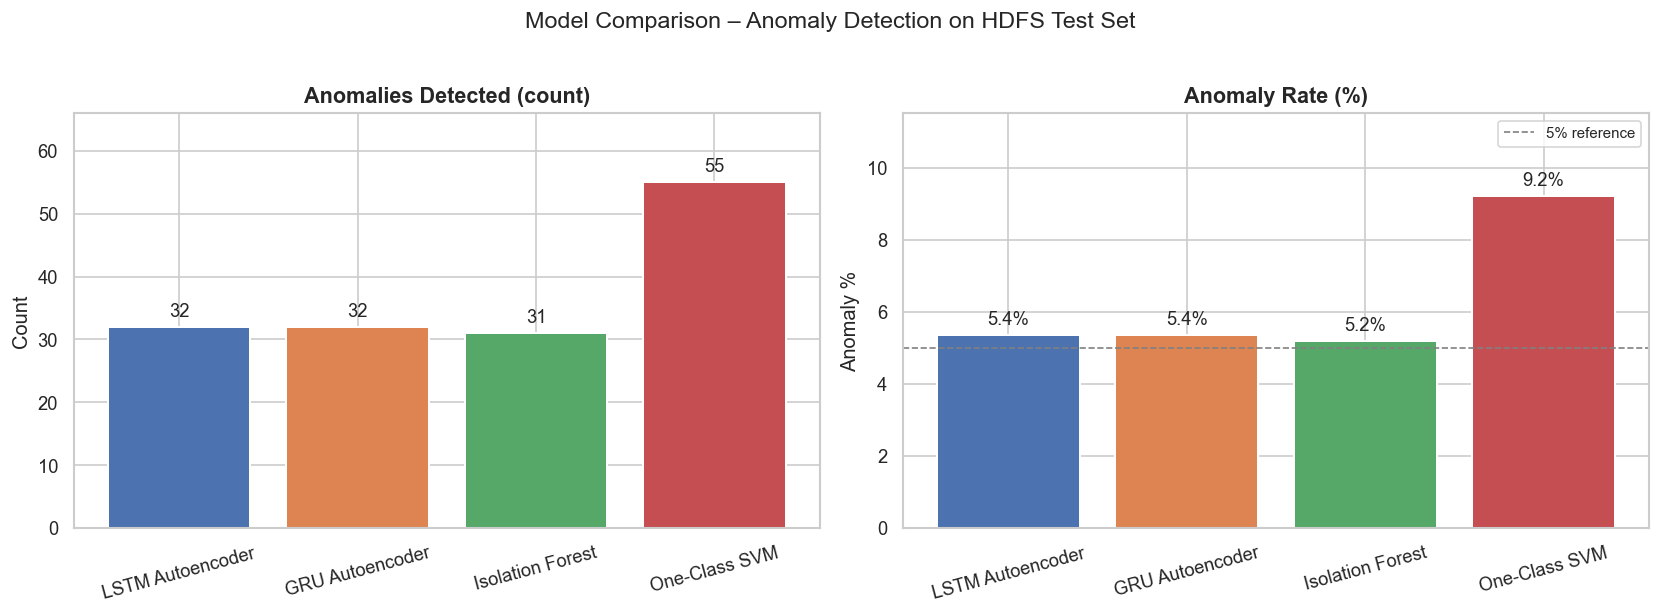

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models     = list(results.keys())
colors     = [MODEL_COLORS[m] for m in models]
n_anomalies = [int(results[m]['labels'].sum()) for m in models]
n_total     = len(test_seq)
anomaly_pct = [v / n_total * 100 for v in n_anomalies]

# --- bar: raw counts ---
bars = axes[0].bar(models, n_anomalies, color=colors, edgecolor='white', linewidth=1.2)
axes[0].bar_label(bars, labels=[f'{v}' for v in n_anomalies], padding=4, fontsize=11)
axes[0].set_title('Anomalies Detected (count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0, max(n_anomalies) * 1.2)

# --- bar: percentage ---
bars2 = axes[1].bar(models, anomaly_pct, color=colors, edgecolor='white', linewidth=1.2)
axes[1].bar_label(bars2, labels=[f'{v:.1f}%' for v in anomaly_pct], padding=4, fontsize=11)
axes[1].axhline(5, color='gray', linestyle='--', linewidth=1, label='5% reference')
axes[1].set_title('Anomaly Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Anomaly %')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, max(anomaly_pct) * 1.25)
axes[1].legend(fontsize=9)

plt.suptitle('Model Comparison – Anomaly Detection on HDFS Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/compare_anomaly_counts.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 4 – Visualisation 2: Normalised anomaly scores per model

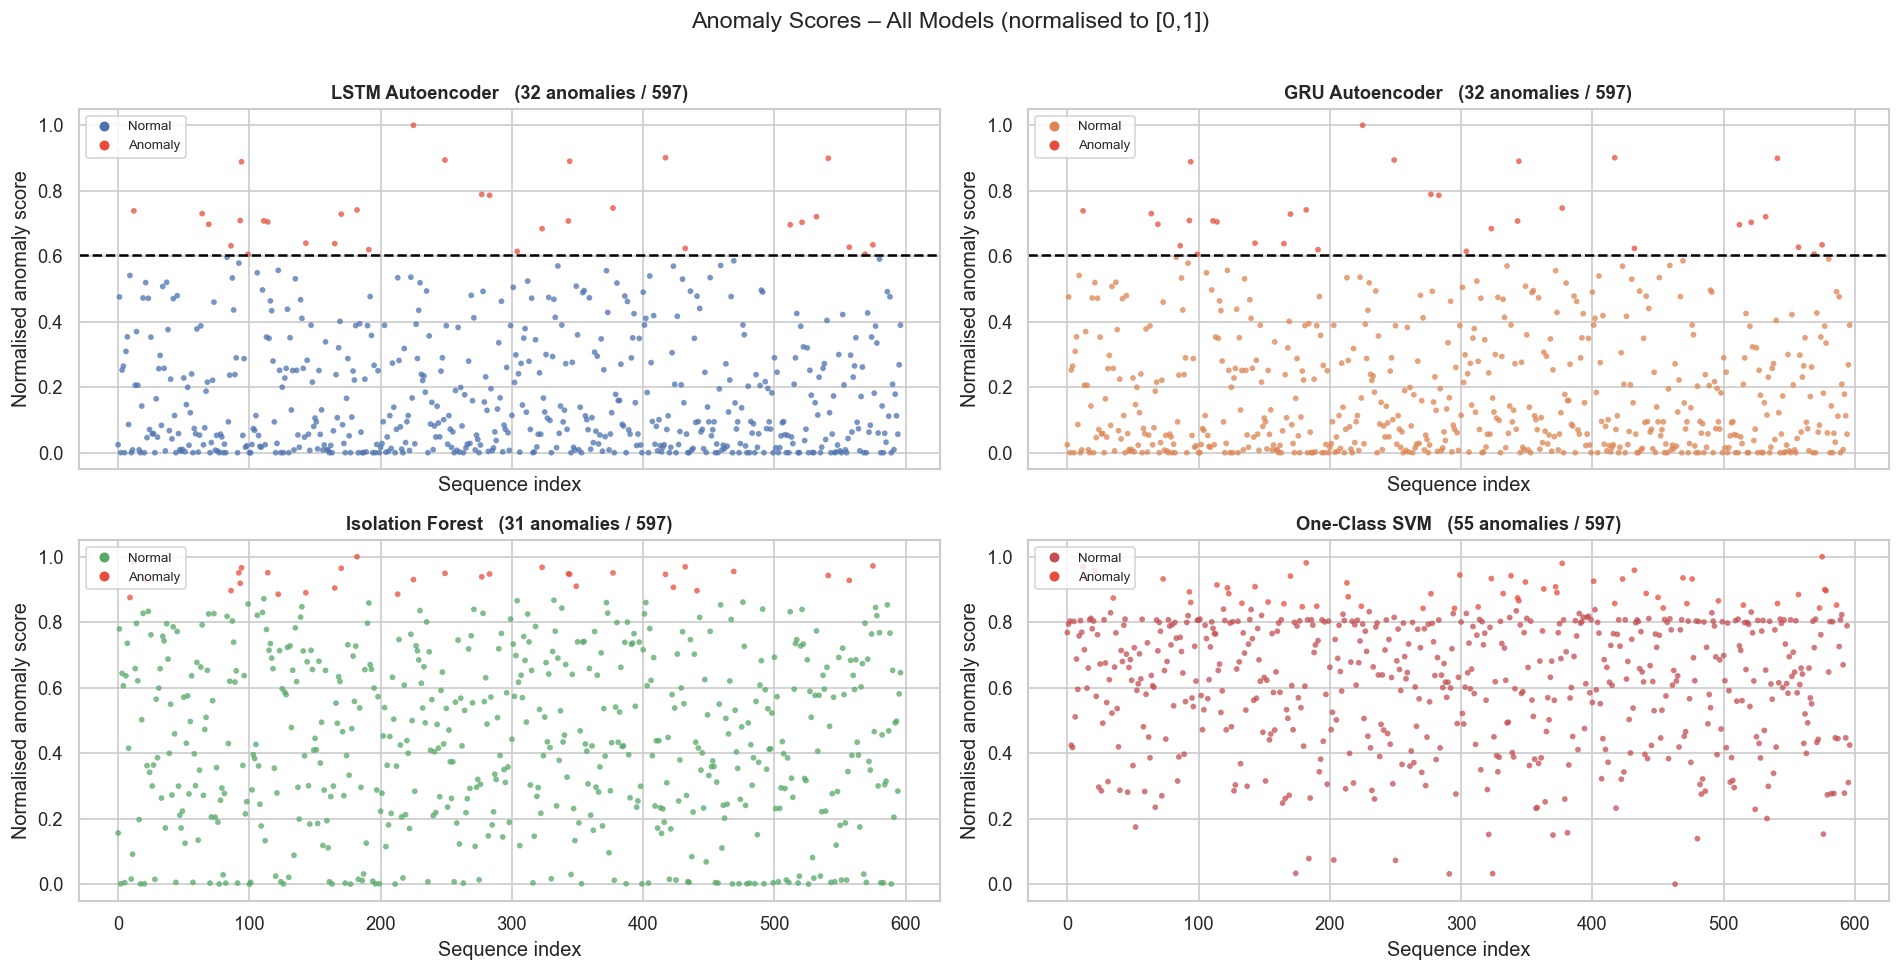

In [17]:
# Normalise all scores to [0, 1] for fair visual comparison
def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-9)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    norm_scores = minmax(res['scores'])
    labels      = res['labels']
    color       = MODEL_COLORS[name]

    # Plot normals in model colour, anomalies in red
    point_colors = ['#e74c3c' if l == 1 else color for l in labels]
    ax.scatter(range(len(norm_scores)), norm_scores,
               c=point_colors, s=12, alpha=0.75, linewidths=0)

    # Threshold line (only for autoencoders)
    if 'threshold' in res:
        thr_norm = minmax(res['errors'])
        raw_thr  = res['threshold']
        lo, hi   = res['errors'].min(), res['errors'].max()
        thr_y    = (raw_thr - lo) / (hi - lo + 1e-9)
        ax.axhline(thr_y, color='black', linestyle='--', linewidth=1.5, label='threshold')
        ax.legend(fontsize=8)

    n_anom = labels.sum()
    ax.set_title(f'{name}   ({n_anom} anomalies / {len(labels)})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Normalised anomaly score')
    ax.set_xlabel('Sequence index')

    # Custom legend handles
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=color,    markersize=7, label='Normal'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=7, label='Anomaly'),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper left')

plt.suptitle('Anomaly Scores – All Models (normalised to [0,1])', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/compare_scores.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 5 – Visualisation 3: Score distributions (KDE)

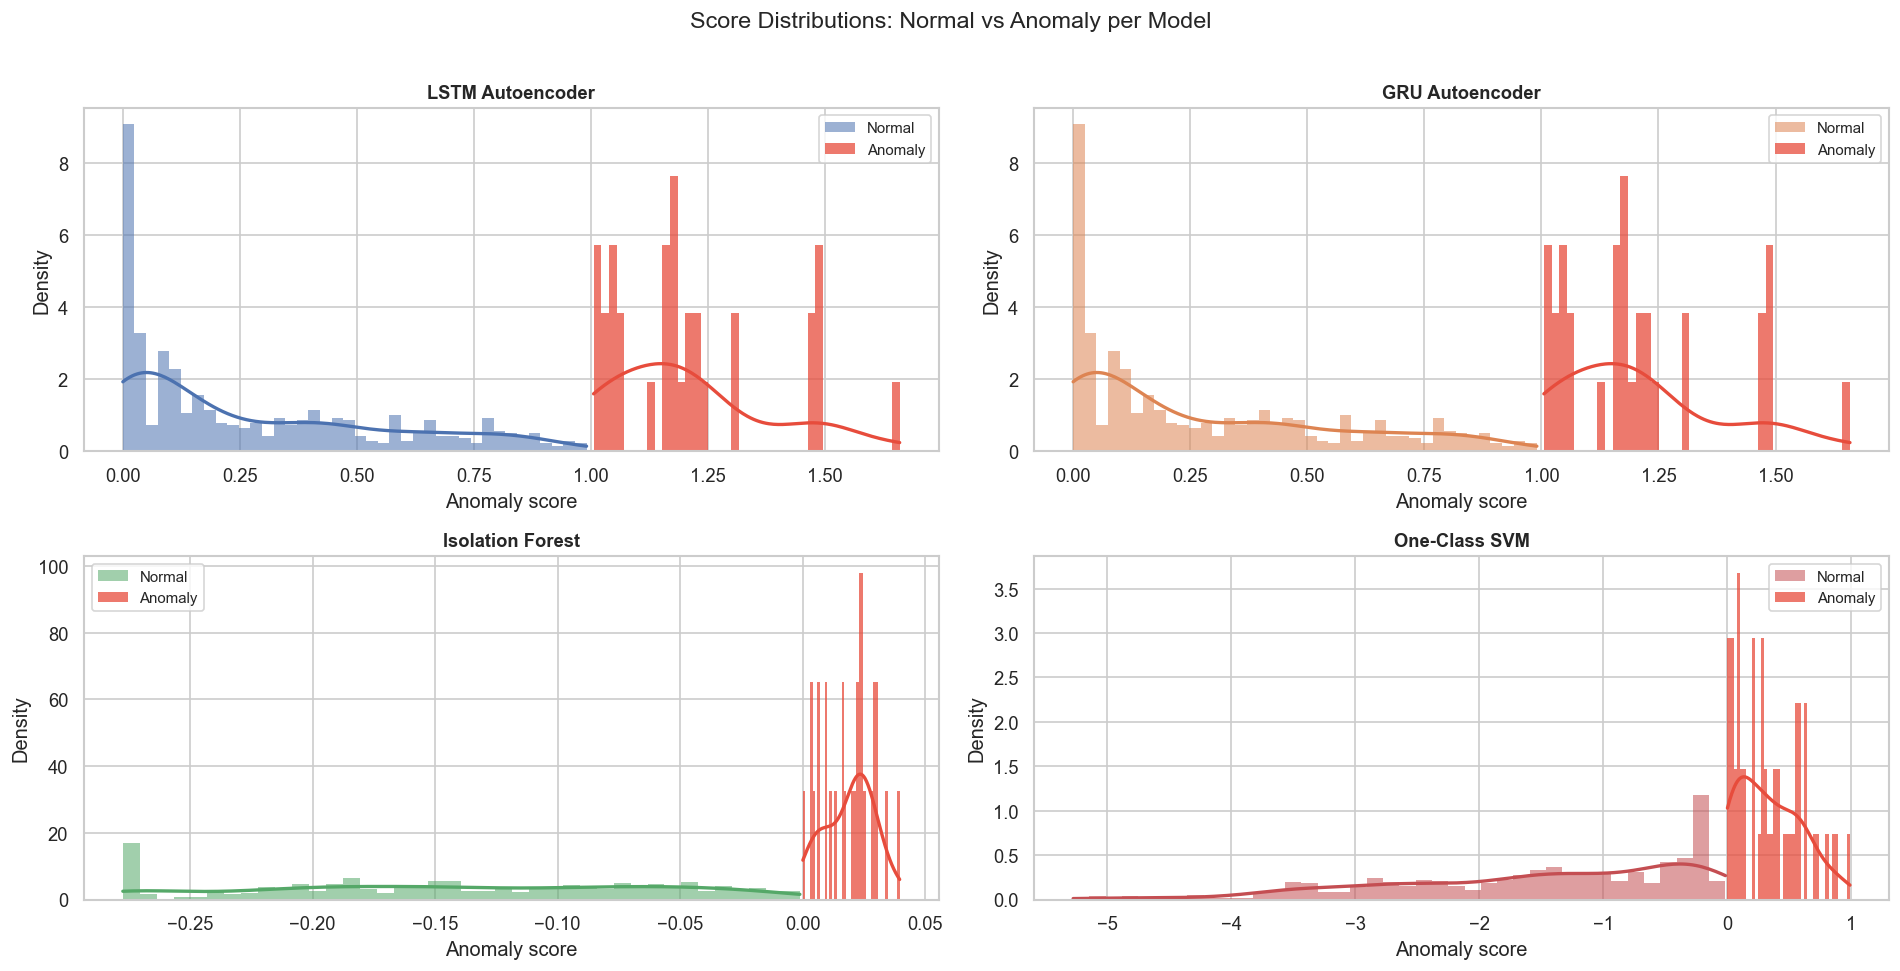

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    scores = res['scores']
    labels = res['labels']
    color  = MODEL_COLORS[name]

    normal_scores  = scores[labels == 0]
    anomaly_scores = scores[labels == 1]

    ax.hist(normal_scores,  bins=40, density=True, alpha=0.55, color=color,    label='Normal',  edgecolor='none')
    ax.hist(anomaly_scores, bins=40, density=True, alpha=0.75, color='#e74c3c', label='Anomaly', edgecolor='none')

    try:
        from scipy.stats import gaussian_kde
        for s, c in [(normal_scores, color), (anomaly_scores, '#e74c3c')]:
            if len(s) > 1:
                kde = gaussian_kde(s)
                xs  = np.linspace(s.min(), s.max(), 200)
                ax.plot(xs, kde(xs), color=c, linewidth=2)
    except ImportError:
        pass   # scipy optional

    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Anomaly score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Score Distributions: Normal vs Anomaly per Model', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/compare_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 6 – Visualisation 4: Agreement heatmap (which sequences are flagged by how many models?)

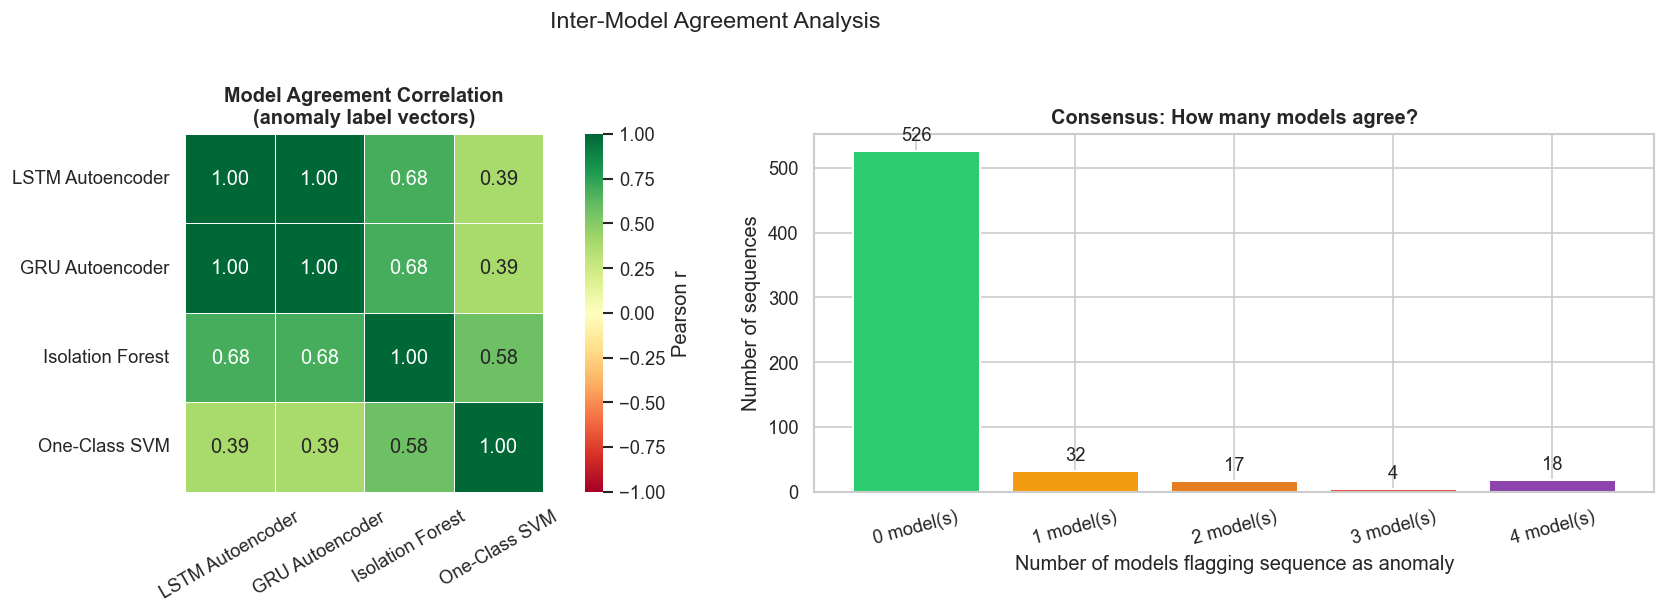

Sequences flagged by ALL 4 models: 18
Sequences flagged by at least 3:   22
Sequences flagged by nobody:       526


In [19]:
# Build label matrix  (models × sequences)
label_matrix = np.array([results[m]['labels'] for m in models])   # shape (4, N_test)
vote_counts  = label_matrix.sum(axis=0)                            # 0-4 votes per sequence

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: correlation heatmap between model labels ---
import pandas as pd
label_df = pd.DataFrame(label_matrix.T, columns=models).astype(float)
corr     = label_df.corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
mask[np.diag_indices_from(mask)] = False

sns.heatmap(
    corr, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, linewidths=0.5, square=True,
    cbar_kws={'label': 'Pearson r'}
)
axes[0].set_title('Model Agreement Correlation\n(anomaly label vectors)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# --- Right: histogram of vote counts ---
vote_palette = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
vote_labels  = [f'{k} model(s)' for k in range(5)]
vote_hist    = [int((vote_counts == k).sum()) for k in range(5)]

bars = axes[1].bar(vote_labels, vote_hist,
                   color=vote_palette, edgecolor='white', linewidth=1.2)
axes[1].bar_label(bars, labels=[str(v) if v > 0 else '' for v in vote_hist],
                  padding=4, fontsize=11)
axes[1].set_title('Consensus: How many models agree?', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of models flagging sequence as anomaly')
axes[1].set_ylabel('Number of sequences')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Inter-Model Agreement Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/compare_agreement.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary
unanimous_anomalies = int((vote_counts == 4).sum())
print(f'Sequences flagged by ALL 4 models: {unanimous_anomalies}')
print(f'Sequences flagged by at least 3:   {int((vote_counts >= 3).sum())}')
print(f'Sequences flagged by nobody:       {int((vote_counts == 0).sum())}')

## Step 7 – Ensemble: flag only sequences flagged by ≥2 models

In [ ]:
for threshold_votes in [1, 2, 3, 4]:
    ensemble_labels = (vote_counts >= threshold_votes).astype(int)
    n_anom = ensemble_labels.sum()
    pct    = n_anom / len(ensemble_labels) * 100
    print(f'Ensemble (≥{threshold_votes} votes): {n_anom:>4} anomalies  ({pct:.1f}%)')

## Summary

| Model | Strength | Weakness |
|-------|----------|----------|
| **LSTM AE** | Captures long-range temporal patterns | Slow to train; needs more data |
| **GRU AE** | Faster than LSTM; similar accuracy | Still needs enough data |
| **Isolation Forest** | Very fast; no labels needed | Ignores sequence order |
| **One-Class SVM** | Good at tight normal clusters | Slow on large datasets; sensitive to scaling |

**Recommended decision rule**: flag sequences that *at least 2 models* agree are anomalous → reduces false positives from any single model.